In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
data = pd.read_csv('AirPassengers (1).csv')

In [39]:
data['Month'] = pd.to_datetime(data['Month'])
data = data.set_index('Month')
data.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [40]:
val_data = data.copy()

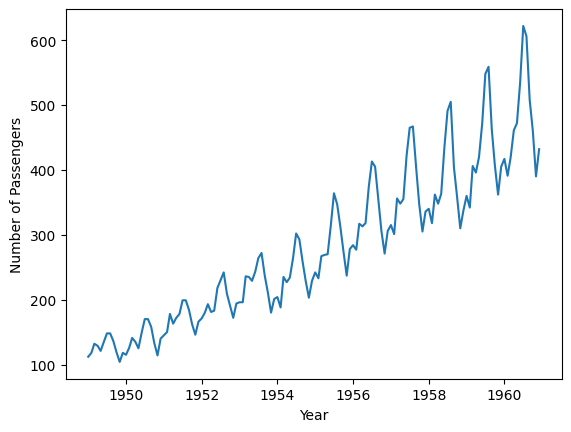

In [18]:
plt.plot(data)
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.show()

### SimpleExpSmoothing

In [19]:
data = data.asfreq('MS')

In [20]:
from statsmodels.tsa.api import SimpleExpSmoothing
model = SimpleExpSmoothing(data)
model_single_fit = model.fit()

In [21]:
forecast_single = model_single_fit.forecast(6)

In [22]:
forecast_single

1961-01-01    431.791781
1961-02-01    431.791781
1961-03-01    431.791781
1961-04-01    431.791781
1961-05-01    431.791781
1961-06-01    431.791781
Freq: MS, dtype: float64

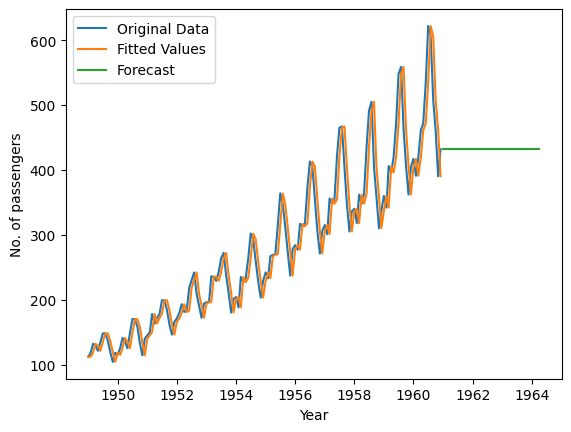

In [23]:
forecast_single = model_single_fit.forecast(40)
plt.plot(data, label='Original Data')
plt.plot(model_single_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_single, label='Forecast')
plt.xlabel('Year')
plt.ylabel('No. of passengers')
plt.legend()
plt.show()

### Holt linear method

In [24]:
from statsmodels.tsa.api import Holt

model_double = Holt(data)
model_double_fit = model_double.fit()

In [25]:
forecast_double = model_double_fit.forecast(6)
forecast_double

1961-01-01    436.196220
1961-02-01    440.578651
1961-03-01    444.961083
1961-04-01    449.343515
1961-05-01    453.725946
1961-06-01    458.108378
Freq: MS, dtype: float64

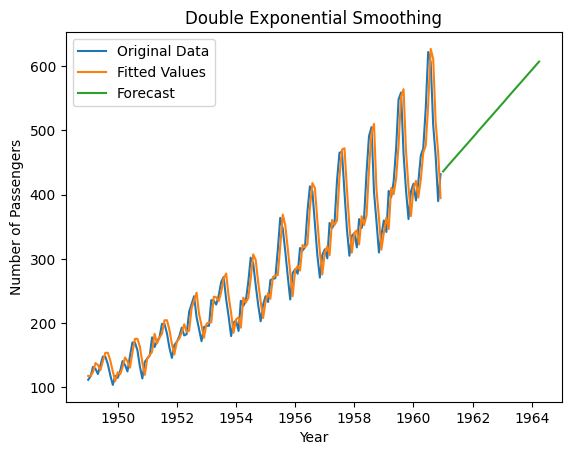

In [26]:
forecast_double = model_double_fit.forecast(40)
plt.plot(data, label='Original Data')
plt.plot(model_double_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_double, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Double Exponential Smoothing')
plt.legend()
plt.show()

### Holt-Winter’s Seasonal Smoothing

In [28]:
from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(data,
                                   seasonal_periods=12,
                                   trend='add',
                                   seasonal='add')
model_triple_fit = model_triple.fit()

In [29]:
forecast_triple = model_triple_fit.forecast(6)
forecast_triple

1961-01-01    451.577073
1961-02-01    427.257748
1961-03-01    464.699360
1961-04-01    500.103185
1961-05-01    508.660794
1961-06-01    567.713873
Freq: MS, dtype: float64

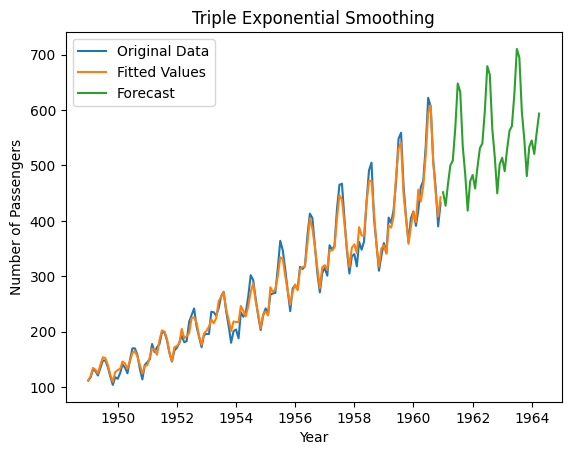

In [30]:
forecast_triple = model_triple_fit.forecast(40)
plt.plot(data, label='Original Data')
plt.plot(model_triple_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_triple, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Triple Exponential Smoothing')
plt.legend()
plt.show()

In [32]:
model_triple_fit.params

{'smoothing_level': 0.25254989686499935,
 'smoothing_trend': 9.765463812739731e-07,
 'smoothing_seasonal': 0.7474446031813125,
 'damping_trend': nan,
 'initial_level': 118.43092695514434,
 'initial_trend': 2.59469363494243,
 'initial_seasons': array([ -9.06562263,  -3.43708014,   9.00565253,   3.81742261,
         -4.93283548,   9.17620296,  21.3830049 ,  18.84610688,
          4.61900836, -14.34042469, -28.91443539, -12.43815072]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

### Evaluation

In [59]:
val_data.shape

(144, 1)

In [60]:
val_data = val_data.asfreq('MS')

In [61]:
train = val_data.iloc[:-12]
test = val_data.iloc[-12:]

In [62]:
train.shape, test.shape

((132, 1), (12, 1))

In [63]:
from statsmodels.tsa.api import ExponentialSmoothing

model = ExponentialSmoothing(train,
                            seasonal_periods=12,
                            trend='add',
                            seasonal='add')
fit = model.fit()
forecast = fit.forecast(len(test))

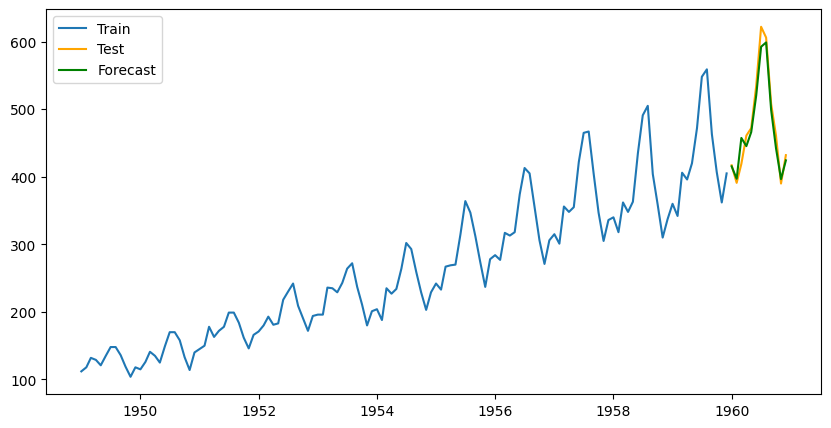

In [64]:
plt.figure(figsize=(10, 5))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='orange')
plt.plot(forecast, label='Forecast', color='green')
plt.legend()
plt.show()

In [69]:
test = test["#Passengers"]

In [70]:
print(type(test), type(forecast))
print(test.shape, forecast.shape)

<class 'pandas.core.series.Series'> <class 'pandas.core.series.Series'>
(12,) (12,)


In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

mask = test != 0
mape = np.mean(np.abs((test[mask] - forecast[mask]) / test[mask])) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 13.38
RMSE: 16.98
MAPE: 2.80%


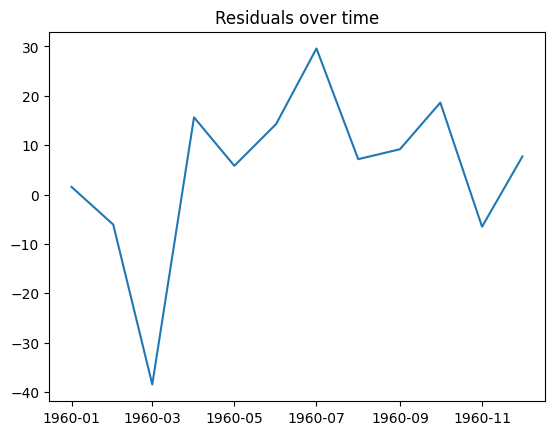

In [72]:
residuals = test - forecast
plt.plot(residuals)
plt.title("Residuals over time")
plt.show()

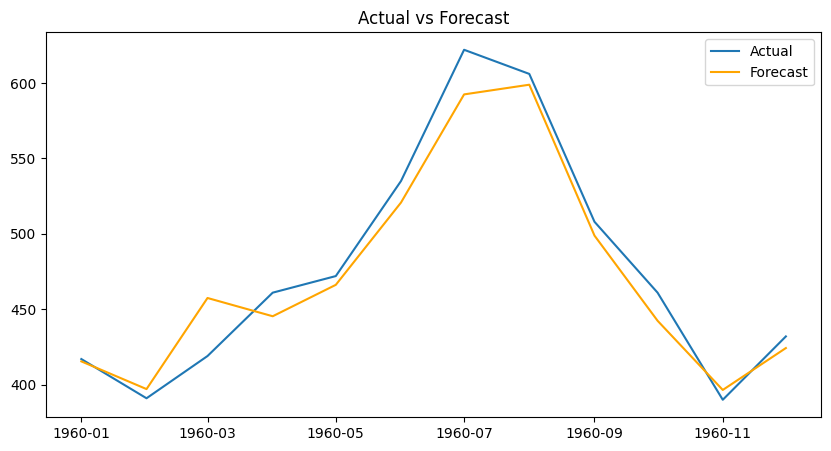

In [73]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast', color='orange')
plt.legend()
plt.title('Actual vs Forecast')
plt.show()